# Assignment 1 - MobileNet Multi-Domain Image Classification

This notebook runs each domain independently. Each domain cell:
- trains for 5 epochs
- saves fresh outputs to `outputs_notebook/<domain>/`
- shows overall metrics
- shows per-class accuracy
- shows the saved figures for that domain only

In [7]:
from pathlib import Path
import json
import random
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Image, display

from configs.config import CONFIG
from domains.base_domain import BaseDomain
from domains.fourier_domain import FourierDomain
from domains.wavelet_domain import WaveletDomain
from domains.hsv_domain import HSVDomain
from models.mobilenet import get_model
from utils.dataset import get_dataloaders
from utils.evaluate import evaluate
from utils.plot import plot_confusion_matrix, plot_curves, save_domain_examples
from utils.train import train_one_epoch

In [8]:
CONFIG['epochs'] = 5
CONFIG['batch_size'] = 32
CONFIG['learning_rate'] = 0.001
CONFIG['image_size'] = 224
CONFIG['train_split'] = 0.70
CONFIG['val_split'] = 0.15
CONFIG['test_split'] = 0.15

OUTPUT_ROOT = Path('outputs_notebook')
OUTPUT_ROOT.mkdir(exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_domain(domain_name):
    registry = {
        'spatial': BaseDomain,
        'fourier': FourierDomain,
        'wavelet': WaveletDomain,
        'hsv': HSVDomain,
    }
    if domain_name not in registry:
        raise ValueError(f'Unsupported domain: {domain_name}')
    return registry[domain_name]()

def compute_confusion_matrix(predictions, labels, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, predicted_label in zip(labels, predictions):
        matrix[true_label, predicted_label] += 1
    return matrix

def compute_per_class_accuracy(confusion_matrix):
    rows = []
    for class_index in range(confusion_matrix.shape[0]):
        total = confusion_matrix[class_index].sum()
        correct = confusion_matrix[class_index, class_index]
        accuracy = (correct / total) if total > 0 else 0.0
        rows.append({
            'Class': class_index,
            'Correct': int(correct),
            'Total': int(total),
            'Per-Class Accuracy': float(accuracy),
        })
    return rows

def run_and_display(domain_name):
    set_seed(CONFIG['seed'])
    domain = get_domain(domain_name)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    output_dir = OUTPUT_ROOT / domain.name

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f'Starting domain={domain.name} on device={device}')
    print(f"epochs={CONFIG['epochs']} | batch_size={CONFIG['batch_size']} | lr={CONFIG['learning_rate']}")

    train_loader, val_loader, test_loader = get_dataloaders(domain)
    save_domain_examples(train_loader.dataset, output_dir / 'domain_examples.png')

    model = get_model(CONFIG['num_classes']).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(CONFIG['epochs']):
        print(f'Epoch {epoch + 1}/{CONFIG["epochs"]}')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f'Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | '
            f'Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}'
        )

    test_loss, test_acc, predictions, labels = evaluate(model, test_loader, criterion, device)
    confusion_matrix = compute_confusion_matrix(predictions, labels, CONFIG['num_classes'])
    per_class_accuracy = compute_per_class_accuracy(confusion_matrix)
    class_names = [str(i) for i in range(CONFIG['num_classes'])]

    plot_curves(history, output_dir)
    plot_confusion_matrix(confusion_matrix, class_names, output_dir / 'confusion_matrix.png')

    results = {
        'domain': domain.name,
        'config': dict(CONFIG),
        'train_loss': history['train_loss'],
        'train_acc': history['train_acc'],
        'val_loss': history['val_loss'],
        'val_acc': history['val_acc'],
        'test_loss': test_loss,
        'test_acc': test_acc,
        'confusion_matrix': confusion_matrix.tolist(),
        'per_class_accuracy': per_class_accuracy,
    }

    with open(output_dir / 'results.json', 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2)

    torch.save(model.state_dict(), output_dir / 'mobilenet_weights.pth')

    summary = pd.DataFrame([
        {
            'Domain': domain.name,
            'Epochs': CONFIG['epochs'],
            'Final Train Accuracy': history['train_acc'][-1],
            'Best Validation Accuracy': max(history['val_acc']),
            'Test Accuracy': test_acc,
            'Test Loss': test_loss,
        }
    ])
    display(summary)
    display(pd.DataFrame(per_class_accuracy))

    display(Image(filename=str(output_dir / 'domain_examples.png')))
    display(Image(filename=str(output_dir / 'accuracy_curve.png')))
    display(Image(filename=str(output_dir / 'loss_curve.png')))
    display(Image(filename=str(output_dir / 'confusion_matrix.png')))

    return results

print('Helpers ready.')
print(f"Notebook output directory: {OUTPUT_ROOT.resolve()}")
print(f"All domains will run with {CONFIG['epochs']} epochs.")

Helpers ready.
Notebook output directory: C:\Users\mohmd\Downloads\IMAGE\outputs_notebook
All domains will run with 5 epochs.


## Spatial Domain Cell

Starting domain=spatial on device=cpu
epochs=5 | batch_size=32 | lr=0.001
Epoch 1/5
Train Loss=0.5734 | Train Acc=0.8080 | Val Loss=0.3688 | Val Acc=0.8768
Epoch 2/5
Train Loss=0.3583 | Train Acc=0.8785 | Val Loss=0.3584 | Val Acc=0.8784
Epoch 3/5
Train Loss=0.2871 | Train Acc=0.9028 | Val Loss=0.3130 | Val Acc=0.8969
Epoch 4/5
Train Loss=0.2383 | Train Acc=0.9163 | Val Loss=0.3331 | Val Acc=0.8901
Epoch 5/5
Train Loss=0.2037 | Train Acc=0.9303 | Val Loss=0.2974 | Val Acc=0.9020


,Domain,Epochs,Final Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
0,spatial,5,0.930286,0.902,0.908933,0.27827


,Class,Correct,Total,Per-Class Accuracy
0,0,696,732,0.950820
1,1,738,761,0.969777
2,2,666,793,0.839849
3,3,579,697,0.830703
4,4,667,730,0.913699
5,5,647,759,0.852437
6,6,703,749,0.938585
7,7,709,779,0.910141
8,8,693,752,0.921543
9,9,719,748,0.961230


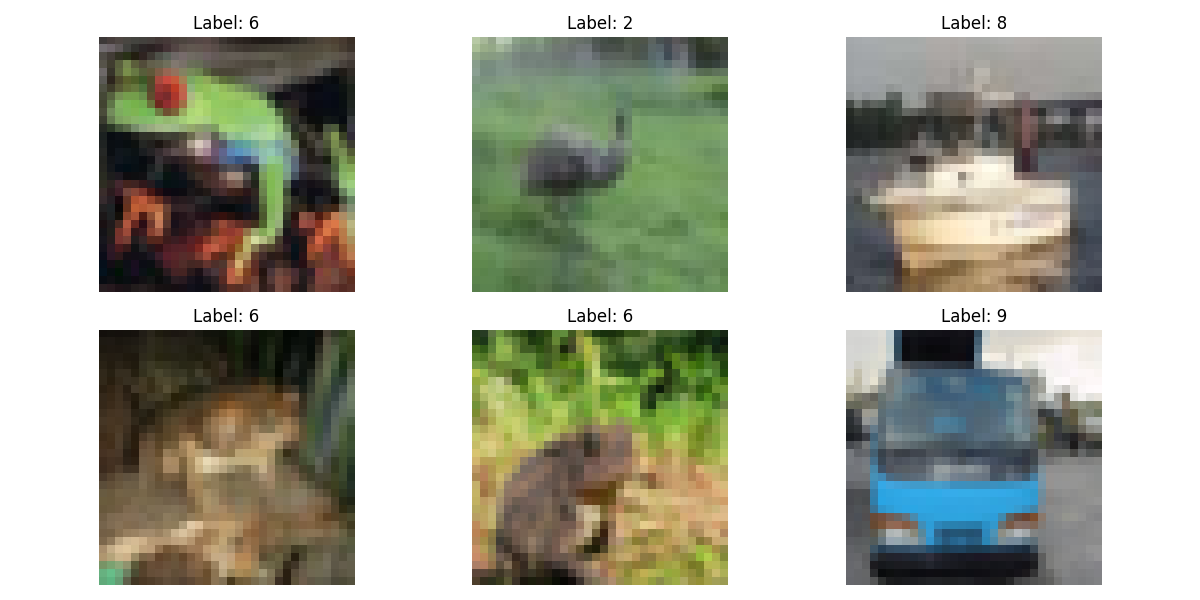

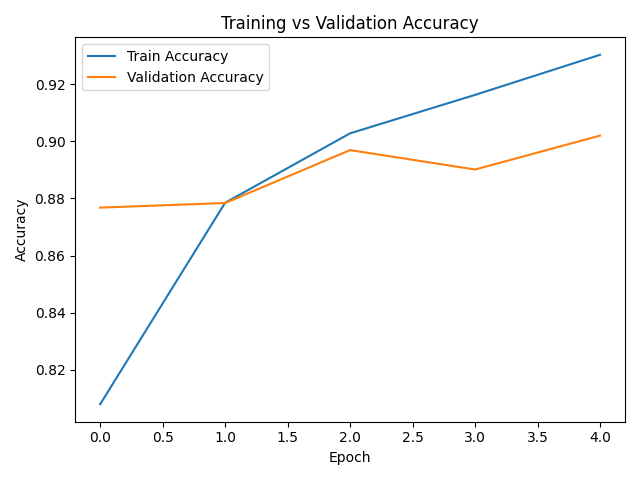

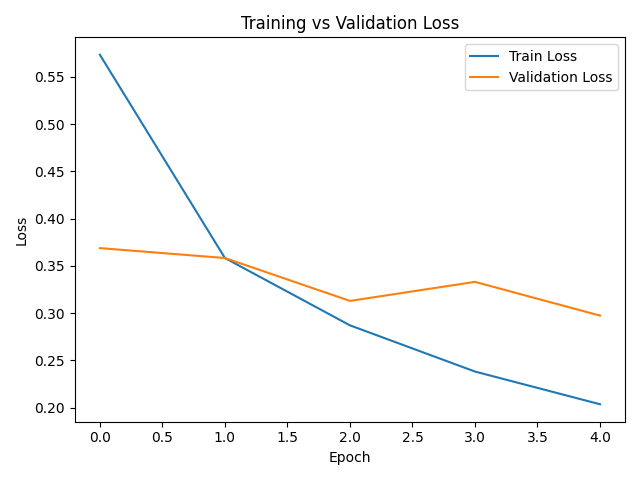

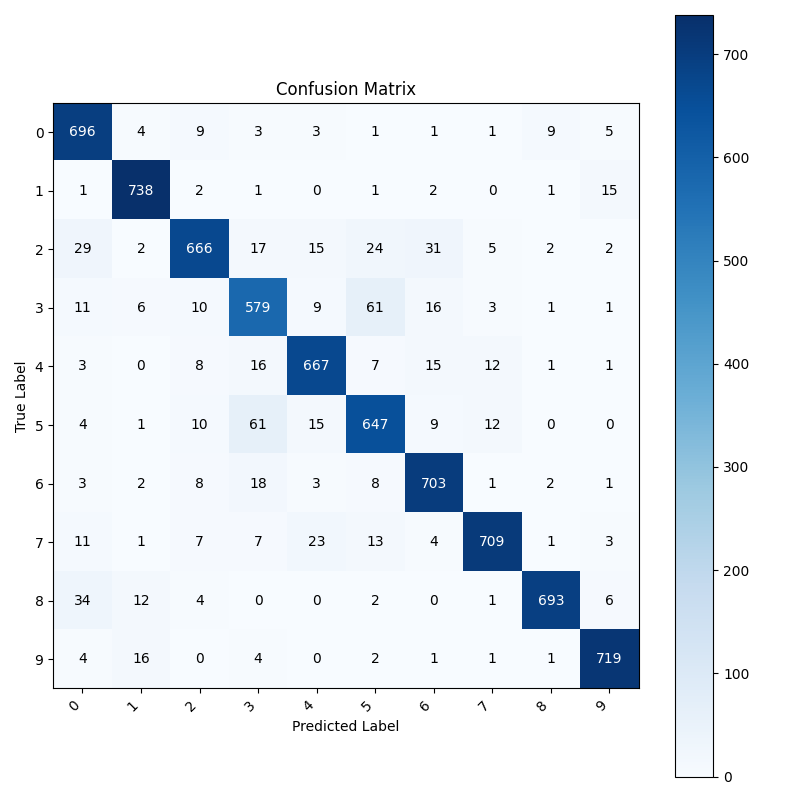

In [9]:
spatial_results = run_and_display('spatial')

## Fourier Domain Cell

Starting domain=fourier on device=cpu
epochs=5 | batch_size=32 | lr=0.001
Epoch 1/5
Train Loss=1.6058 | Train Acc=0.4151 | Val Loss=1.4350 | Val Acc=0.4821
Epoch 2/5
Train Loss=1.3596 | Train Acc=0.5073 | Val Loss=1.3816 | Val Acc=0.5008
Epoch 3/5
Train Loss=1.2733 | Train Acc=0.5387 | Val Loss=1.2476 | Val Acc=0.5516
Epoch 4/5
Train Loss=1.1968 | Train Acc=0.5696 | Val Loss=1.2371 | Val Acc=0.5523
Epoch 5/5
Train Loss=1.1363 | Train Acc=0.5861 | Val Loss=1.2075 | Val Acc=0.5640


,Domain,Epochs,Final Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
0,fourier,5,0.586086,0.564,0.546667,1.257436


,Class,Correct,Total,Per-Class Accuracy
0,0,549,732,0.750000
1,1,452,761,0.593955
2,2,314,793,0.395965
3,3,192,697,0.275466
4,4,333,730,0.456164
5,5,430,759,0.566535
6,6,546,749,0.728972
7,7,403,779,0.517330
8,8,424,752,0.563830
9,9,457,748,0.610963


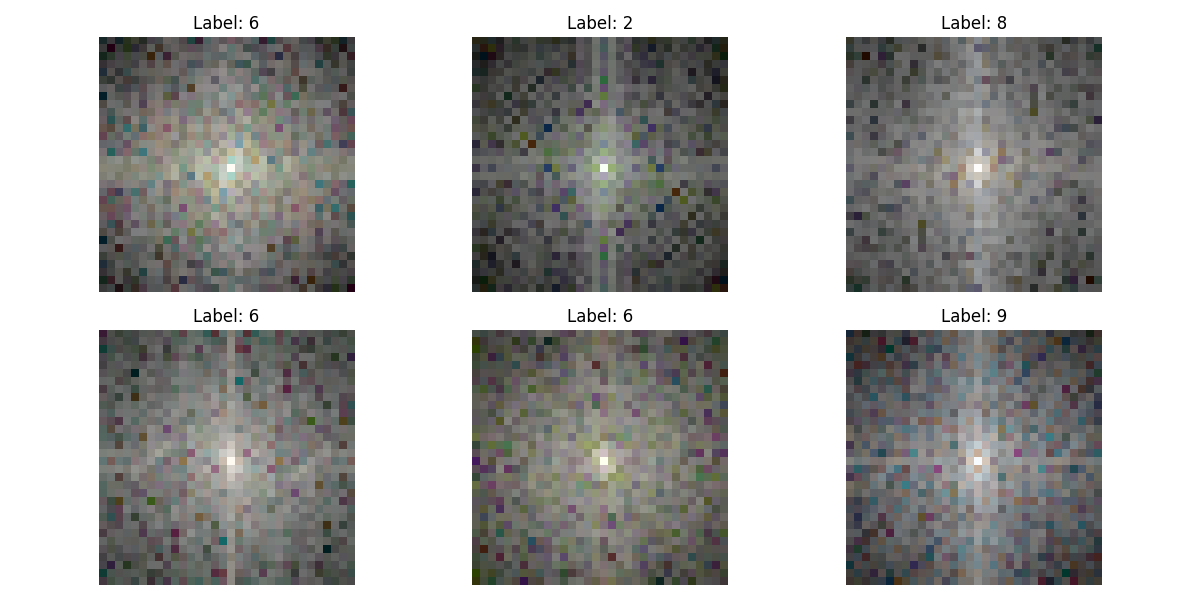

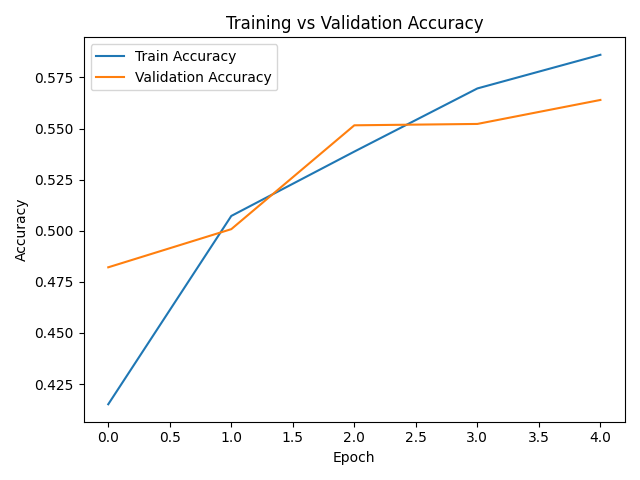

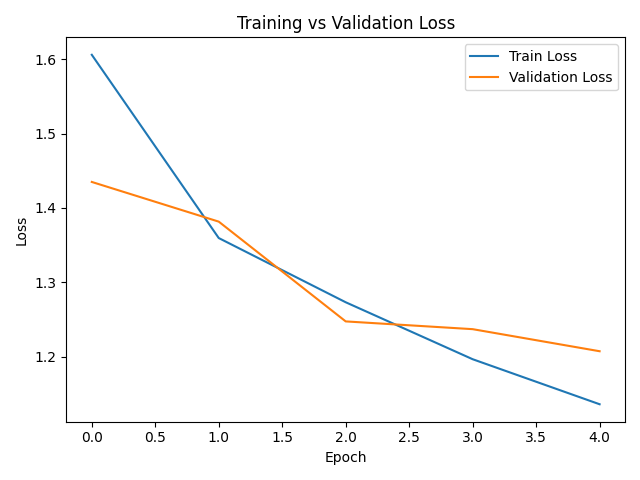

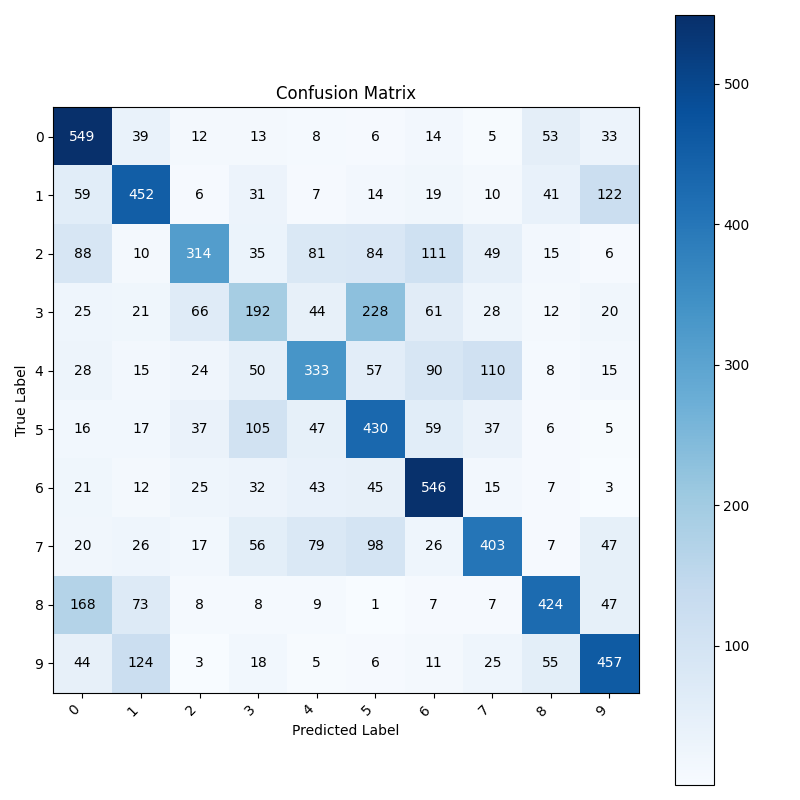

In [10]:
fourier_results = run_and_display('fourier')

## Wavelet Domain Cell

Starting domain=wavelet on device=cpu
epochs=5 | batch_size=32 | lr=0.001
Epoch 1/5
Train Loss=0.8299 | Train Acc=0.7140 | Val Loss=0.6070 | Val Acc=0.7953
Epoch 2/5
Train Loss=0.5492 | Train Acc=0.8113 | Val Loss=0.5463 | Val Acc=0.8153
Epoch 3/5
Train Loss=0.4526 | Train Acc=0.8446 | Val Loss=0.4805 | Val Acc=0.8352
Epoch 4/5
Train Loss=0.3773 | Train Acc=0.8709 | Val Loss=0.4713 | Val Acc=0.8435
Epoch 5/5
Train Loss=0.3242 | Train Acc=0.8863 | Val Loss=0.4847 | Val Acc=0.8447


,Domain,Epochs,Final Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
0,wavelet,5,0.886314,0.844667,0.8444,0.47604


,Class,Correct,Total,Per-Class Accuracy
0,0,680,732,0.928962
1,1,703,761,0.923784
2,2,642,793,0.809584
3,3,487,697,0.698709
4,4,610,730,0.835616
5,5,533,759,0.702240
6,6,693,749,0.925234
7,7,681,779,0.874198
8,8,636,752,0.845745
9,9,668,748,0.893048


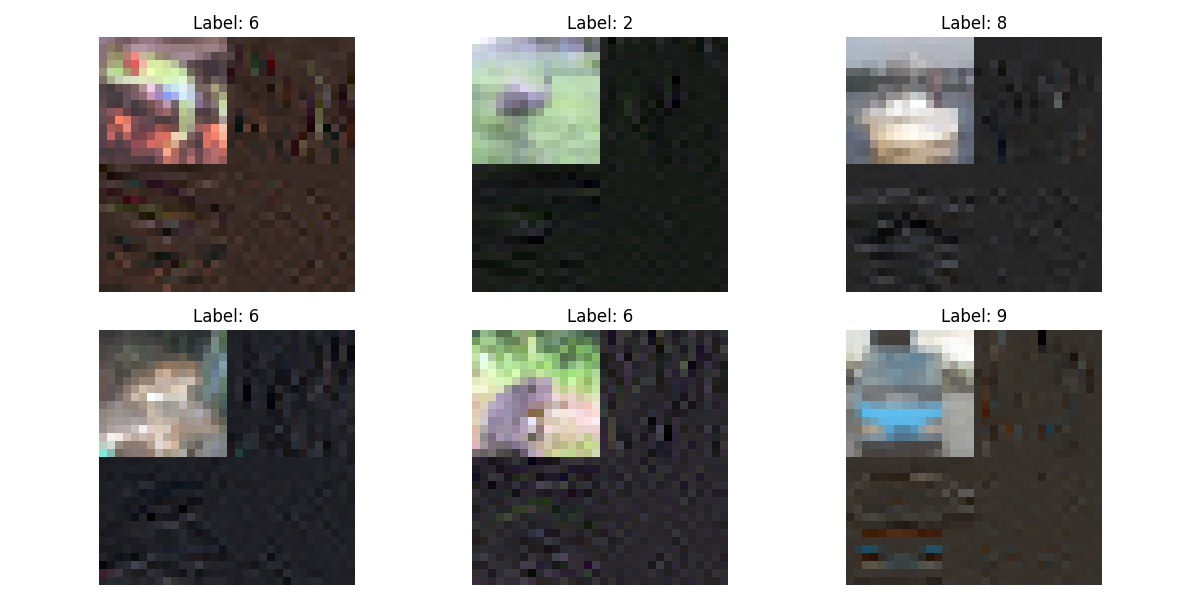

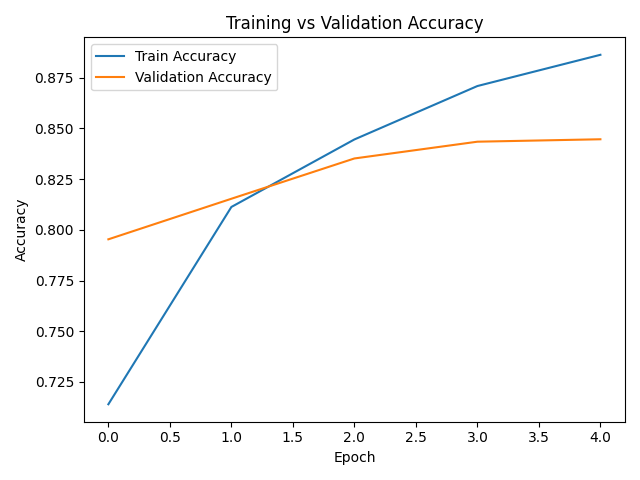

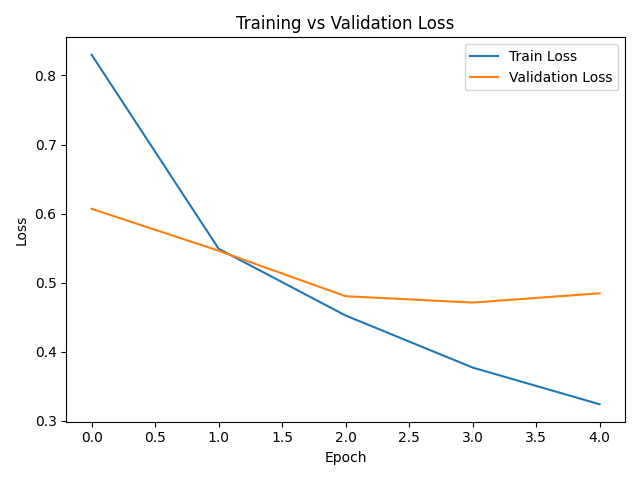

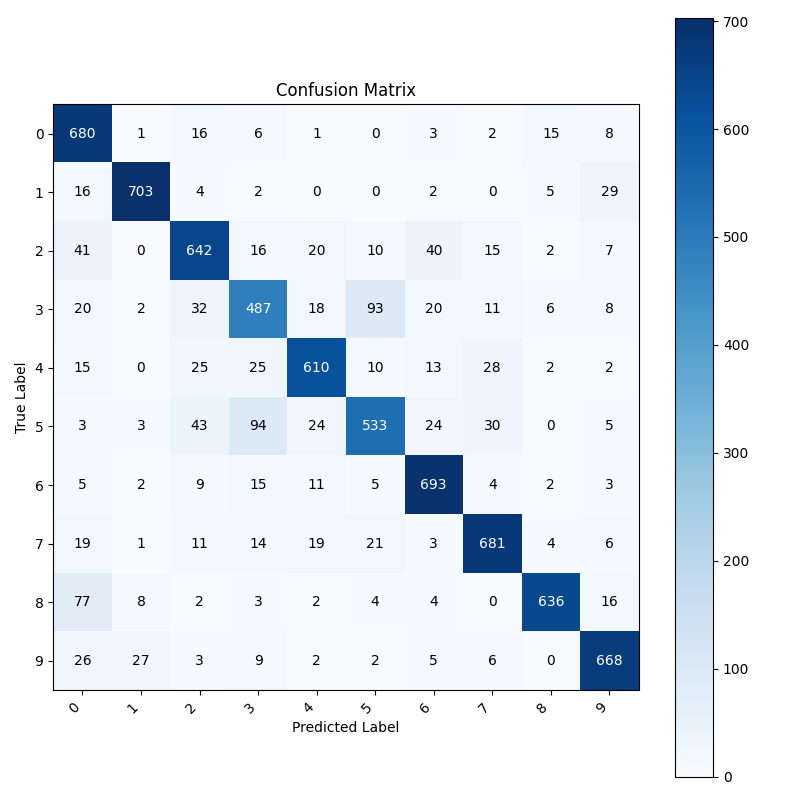

In [11]:
wavelet_results = run_and_display('wavelet')

## HSV Domain Cell

Starting domain=hsv on device=cpu
epochs=5 | batch_size=32 | lr=0.001
Epoch 1/5
Train Loss=0.7715 | Train Acc=0.7369 | Val Loss=0.4906 | Val Acc=0.8344
Epoch 2/5
Train Loss=0.4558 | Train Acc=0.8443 | Val Loss=0.4326 | Val Acc=0.8487
Epoch 3/5
Train Loss=0.3595 | Train Acc=0.8779 | Val Loss=0.3757 | Val Acc=0.8728
Epoch 4/5
Train Loss=0.2955 | Train Acc=0.8986 | Val Loss=0.3391 | Val Acc=0.8859
Epoch 5/5
Train Loss=0.2582 | Train Acc=0.9110 | Val Loss=0.3563 | Val Acc=0.8816


,Domain,Epochs,Final Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
0,hsv,5,0.911029,0.885867,0.886,0.339758


,Class,Correct,Total,Per-Class Accuracy
0,0,695,732,0.949454
1,1,741,761,0.973719
2,2,650,793,0.819672
3,3,516,697,0.740316
4,4,648,730,0.887671
5,5,641,759,0.844532
6,6,679,749,0.906542
7,7,712,779,0.913992
8,8,693,752,0.921543
9,9,670,748,0.895722


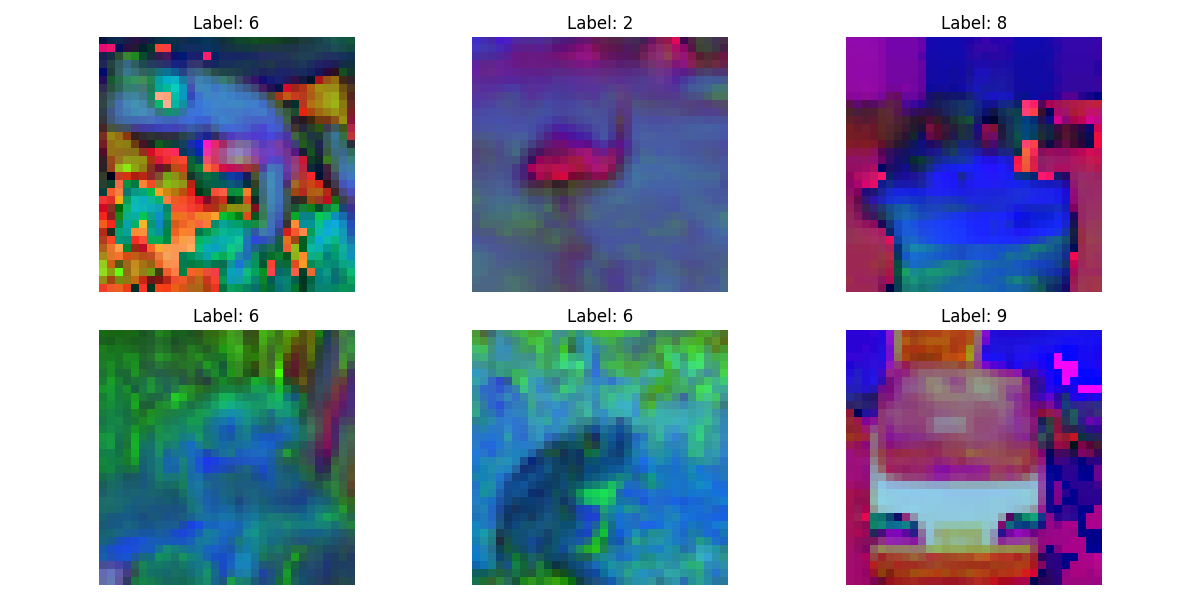

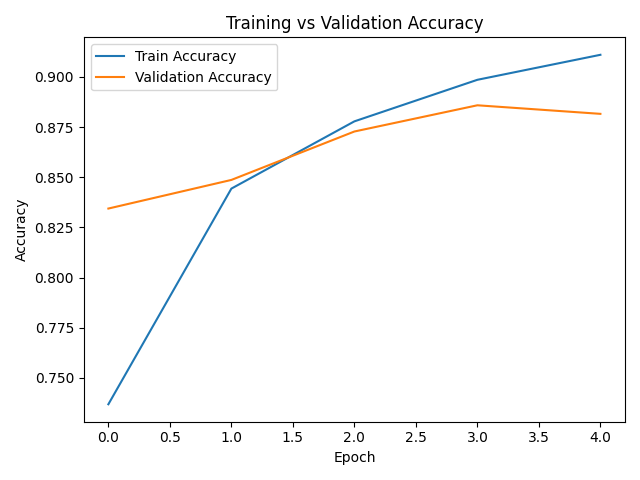

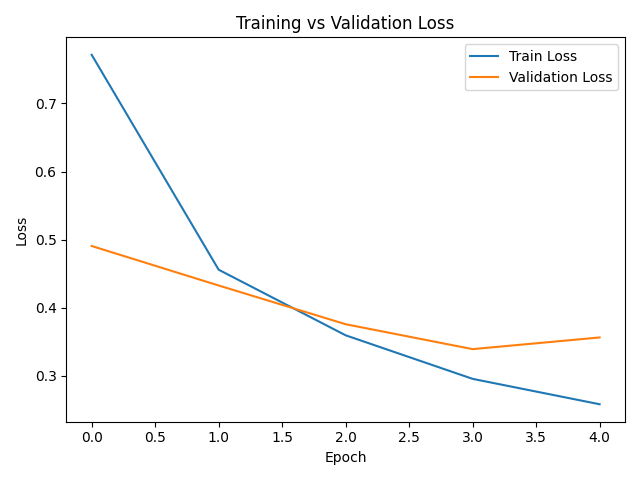

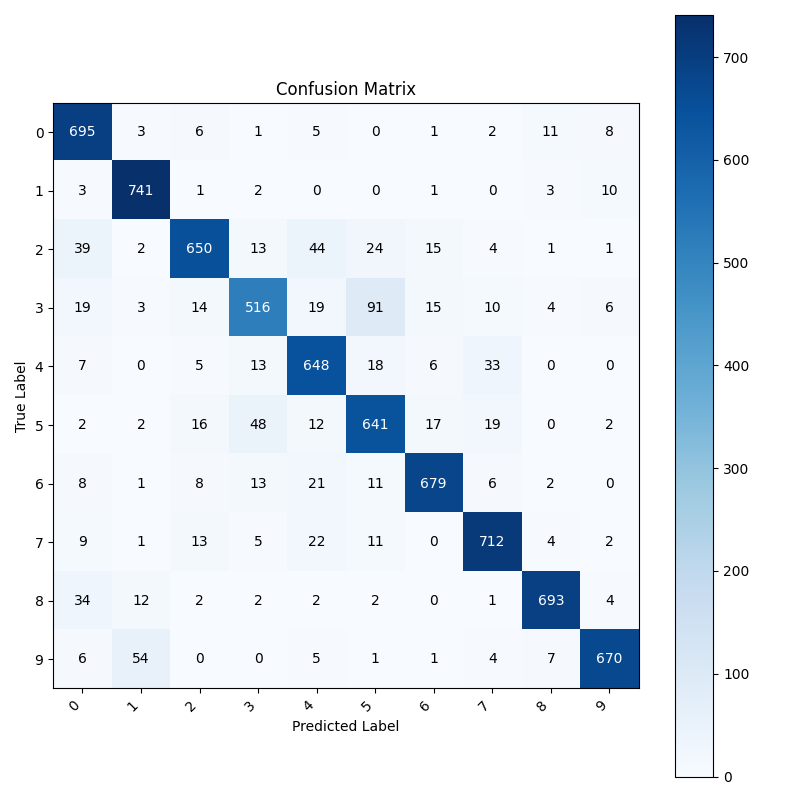

In [12]:
hsv_results = run_and_display('hsv')

## Comparison Table

In [13]:
rows = []
for results_file in sorted(OUTPUT_ROOT.glob('*/results.json')):
    with open(results_file, 'r', encoding='utf-8') as f:
        r = json.load(f)
    rows.append({
        'Domain': r['domain'],
        'Epochs': r['config']['epochs'],
        'Final Train Accuracy': r['train_acc'][-1],
        'Best Validation Accuracy': max(r['val_acc']),
        'Test Accuracy': r['test_acc'],
        'Test Loss': r['test_loss'],
    })

if rows:
    display(pd.DataFrame(rows).sort_values('Domain').reset_index(drop=True))
else:
    print('No domain runs found yet. Execute one of the domain cells first.')

,Domain,Epochs,Final Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
0,fourier,5,0.586086,0.564000,0.546667,1.257436
1,hsv,5,0.911029,0.885867,0.886000,0.339758
2,spatial,5,0.930286,0.902000,0.908933,0.278270
3,wavelet,5,0.886314,0.844667,0.844400,0.476040
